### First analysis of RNA translation efficiency dataset.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
pd.options.mode.chained_assignment = None

In [38]:
# Load dataframe from an Excel file
df_predicted = pd.read_excel("/home/ghassan_unix/MA2/RiboNN/original_data/41587_2025_2712_MOESM5_ESM.xlsx")
df_real = pd.read_excel("/home/ghassan_unix/MA2/RiboNN/original_data/41587_2025_2712_MOESM3_ESM.xlsx")

# Preview
print("size of predicted dataframe:", df_predicted.shape)
print("size of real dataframe:", df_real.shape)

size of predicted dataframe: (10037, 88)
size of real dataframe: (10348, 88)


### 1. Information provided about the sequences

- `gene_id`: Ensemble identifier for a specific gene, e.g `ENSG00000187634.12`
- `tx_id`: Ensemble identifier for a specific transcript, e.g `ENST00000361453.8`. In this paper they only consider one representative isoform per gene. Hence they could be missing differential TE in certain cell types that are due to alternative splicing.

In [39]:
print(df_real["gene_id"].is_unique)
print(df_real["tx_id"].is_unique)

True
True


In [61]:
informative_columns_real = [column for column in df_real.columns if not column.startswith("TE")]
informative_columns_predicted = [column for column in df_predicted.columns if not column.startswith("predicted_TE")]
print("Informative columns in df_real:", informative_columns_real)
print("Informative columns in df_predicted:", informative_columns_predicted)

Informative columns in df_real: ['SYMBOL', 'gene_id', 'tx_id', 'tx_size', 'utr5_size', 'utr3_size', 'cds_size', 'tx_sequence', 'fold', 'mean_te', 'number_missing', 'excluded', 'cds_utr3_len_code', 'cds_utr3_len_notebook']
Informative columns in df_predicted: ['tx_id', 'tx_size', 'utr5_size', 'utr3_size', 'cds_size', 'SYMBOL', 'tx_sequence', 'fold', 'mean_te', 'mean_predicted_TE']


For a given mRNA sequence, TE values are not available for all cell types.

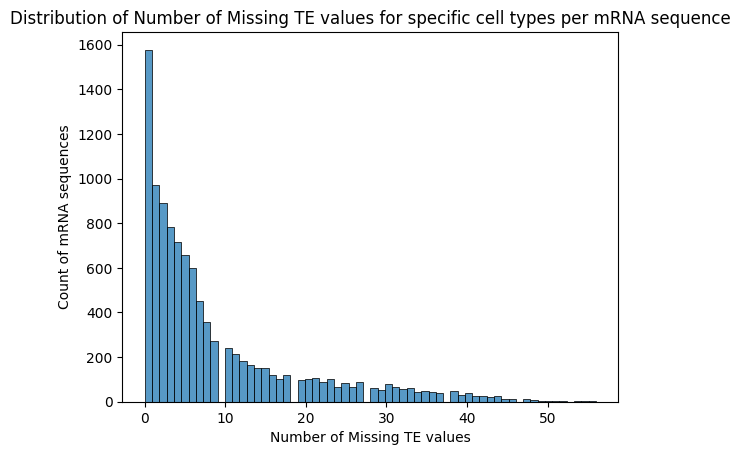

In [41]:
df_real["number_missing"] = df_real.isna().sum(axis=1)
sns.histplot(data=df_real, x="number_missing")
plt.title("Distribution of Number of Missing TE values for specific cell types per mRNA sequence")
plt.xlabel("Number of Missing TE values")
plt.ylabel("Count of mRNA sequences")
plt.show()

### 2. Discrepancy in number of evaluated genes between the real and predicted datasets

In [42]:
print("are all sequences in the predicted dataset present in the real dataset?", df_predicted["tx_id"].isin(df_real["tx_id"]).all())
print("are all sequences in the real dataset present in the predicted dataset?", df_real["tx_id"].isin(df_predicted["tx_id"]).all())
print("number of sequences in the real dataset that are not in the predicted dataset:", (~df_real["tx_id"].isin(df_predicted["tx_id"])).sum(), "/", df_real.shape[0])
df_real["excluded"] = ~df_real["tx_id"].isin(df_predicted["tx_id"])

are all sequences in the predicted dataset present in the real dataset? True
are all sequences in the real dataset present in the predicted dataset? False
number of sequences in the real dataset that are not in the predicted dataset: 311 / 10348


sequences with 5' UTRs longer than 1381 nucleotides and the sequences with combined CDS + 3'UTR lengths higher than 11,937 nucleotides were excluded from the model. This accounts for 106 sequences. This number makes sense with the paper as it is mentioned that evaluation metrics are calculated on n=10,242 sequences, which is 10,348 - 106.

Where the other sequences have disappeared I do not know.

In [43]:
criteria_subset = df_real.loc[(df_real["utr5_size"] > 1381) | (df_real["cds_size"] + df_real["utr3_size"] > 11937) | (df_real["tx_size"]> 12288)]
print(len(criteria_subset))

106


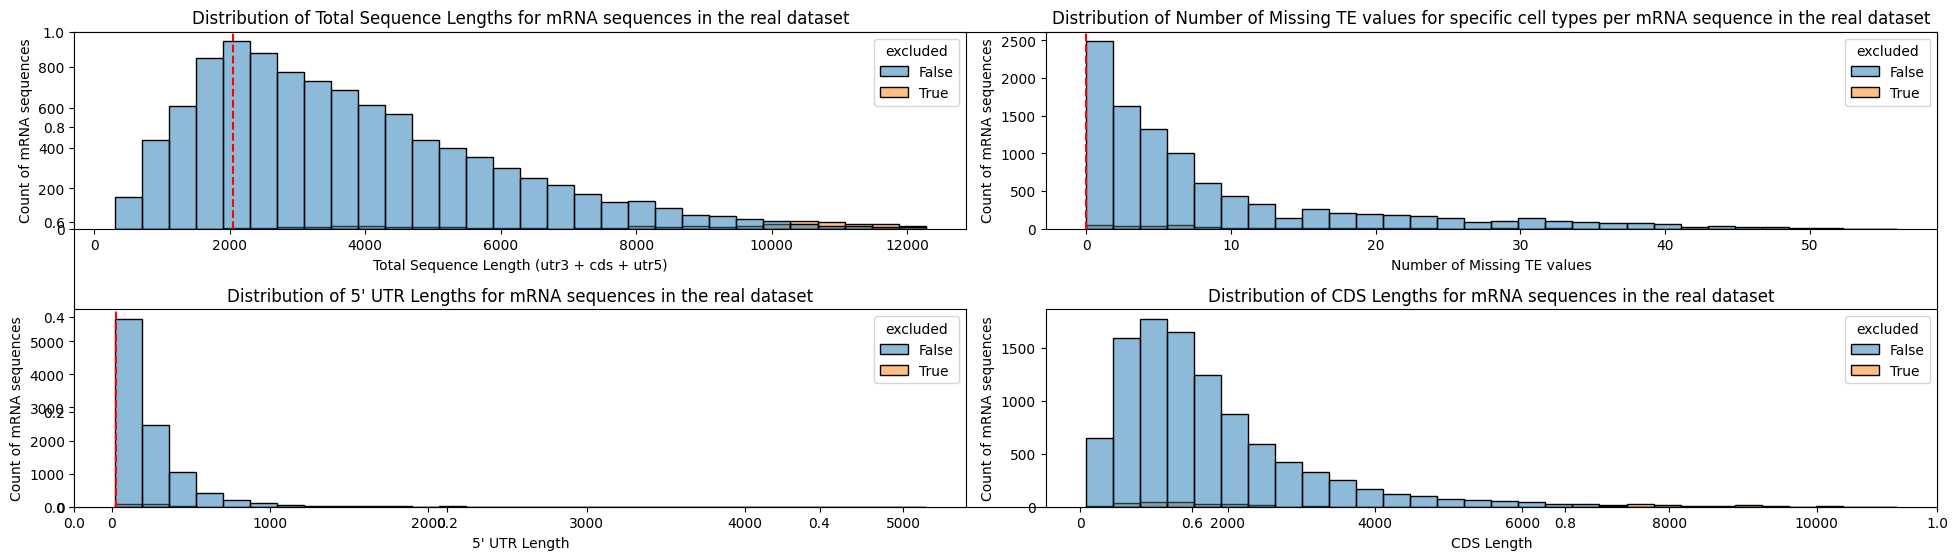

In [47]:
plt.subplots(figsize=(20, 6))
plt.subplot(2, 2, 1)
sns.histplot(data=df_real, x="tx_size", bins=30, hue="excluded")
plt.axvline(df_real.loc[df_real["excluded"], "tx_size"].min(), color="red", linestyle="--", label="Min Total Size of Excluded Sequences")
plt.title("Distribution of Total Sequence Lengths for mRNA sequences in the real dataset")
plt.xlabel("Total Sequence Length (utr3 + cds + utr5)")
plt.ylabel("Count of mRNA sequences")
plt.subplot(2, 2, 2)
sns.histplot(data=df_real, x="number_missing", bins=30, hue="excluded")
plt.axvline(df_real.loc[df_real["excluded"], "number_missing"].min(), color="red", linestyle="--", label="Min Number of Missing TE values for Excluded Sequences")
plt.title("Distribution of Number of Missing TE values for specific cell types per mRNA sequence in the real dataset")
plt.xlabel("Number of Missing TE values")
plt.ylabel("Count of mRNA sequences")
plt.subplot(2, 2, 3)
sns.histplot(data=df_real, x="utr5_size", bins=30, hue="excluded")
plt.axvline(df_real.loc[df_real["excluded"], "utr5_size"].min(), color="red", linestyle="--", label="Min 5' UTR Length of Excluded Sequences")
plt.title("Distribution of 5' UTR Lengths for mRNA sequences in the real dataset")
plt.xlabel("5' UTR Length")
plt.ylabel("Count of mRNA sequences")
plt.subplot(2, 2, 4)
sns.histplot(data=df_real, x="cds_size", bins=30, hue="excluded")
plt.title("Distribution of CDS Lengths for mRNA sequences in the real dataset")
plt.xlabel("CDS Length")
plt.ylabel("Count of mRNA sequences")
plt.tight_layout()


In [48]:
df_real.loc[df_real["excluded"] ]

,SYMBOL,gene_id,tx_id,tx_size,utr5_size,utr3_size,cds_size,tx_sequence,TE_108T,TE_12T,...,TE_neuronal_precursor_cells,TE_neurons,TE_normal_brain_tissue,TE_normal_prostate,TE_primary_macrophages,TE_skeletal_muscle,fold,mean_te,number_missing,excluded
80,MTOR,ENSG00000198793.13,ENST00000361445.9,8721,121,950,7650,GCTCCCGGCTTAGAGGACAGCGGGGAAGGCGGGCGGTGGGGCAGGG...,-0.098298,-0.971177,...,-0.613946,-0.614421,0.519283,-0.308458,NaN,NaN,0,-0.334269,5,True
87,MTHFR,ENSG00000177000.13,ENST00000376592.6,8378,1450,4957,1971,GTCCGCCGGGACCTTTCTGGGAGTCGTAGGCTTAATGACCCTATGC...,-0.563343,-0.162124,...,-0.058110,-0.107587,-0.610603,-0.173234,NaN,NaN,5,-0.229048,5,True
101,DDI2,ENSG00000197312.12,ENST00000480945.6,10667,213,9254,1200,AGACGGACTCGCAGGCGTGTGGCGGCGGCCGTGCTTGCTAGTGAGG...,0.717012,1.082087,...,0.357073,0.319680,3.078784,0.362022,NaN,1.204170,2,0.915590,2,True
135,CDC42,ENSG00000070831.17,ENST00000648594.1,10598,179,9843,576,GGTTCCCGCGCGGCGCTCCAAAGCTCGGGGAGTGGTGGTCTCCCTT...,1.975892,1.284927,...,0.336957,0.661078,1.870888,1.816830,3.323970,4.619349,8,1.855469,0,True
298,RIMKLA,ENSG00000177181.15,ENST00000431473.4,10577,143,9258,1176,GCAGAGACGCCTGGCGCACCCGCGGGAGCGGAGCCGTGGCGCGCTC...,NaN,NaN,...,0.044948,0.108822,0.596710,-0.490322,NaN,NaN,4,-0.304974,28,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10172,ATRX,ENSG00000085224.22,ENST00000373344.10,11167,215,3473,7479,CTCGGCCCAACAAAATGGCGGCGGCAGCGGTGTCGCTTTGTTTCCG...,1.668497,0.669487,...,-0.773535,-0.821851,1.141153,0.152719,NaN,-0.154246,6,-0.043365,4,True
10201,ARMCX5,ENSG00000125962.14,ENST00000604957.1,4640,2622,341,1677,ACTGCCGTTGTGGGTAACGCGGACGTGGAAGAACCTCGTCTGCGGA...,-0.149615,-0.683760,...,0.018315,-0.116050,0.547879,0.578080,NaN,NaN,8,0.026111,6,True
10254,MCTS1,ENSG00000232119.8,ENST00000371317.10,9577,136,8895,546,GTTTTCCGGATAACGACTACAGCTCCGACTGTCAGTGCCGGCCTTC...,0.528614,0.666404,...,0.692347,0.747047,1.453155,1.745142,0.730425,3.121765,4,0.983966,0,True
10325,MECP2,ENSG00000169057.23,ENST00000303391.11,10467,212,8794,1461,GCGCGCGCTCCCTCCTCTCGGAGAGAGGGCTGTGGTAAAAGCCGTC...,-0.991782,-0.740490,...,-0.201007,-0.041636,1.452370,-1.112621,NaN,2.008527,5,-0.420519,4,True


### 2b. Investigating the remaining 205 unexplained exclusions

The length cutoffs (5'UTR > 1381, CDS+3'UTR > 11937, tx_size > 12288) account for 106 of the 311 excluded sequences.
The remaining **205** pass all length filters. We test four hypotheses based on the filtering logic in `src/data.py`:

- **H2**: The CDS+3'UTR length used *in the code* (`tx_size - utr5_size`) differs from `cds_size + utr3_size` for some rows, causing additional exclusions.
- **H3**: Sequences contain non-standard nucleotides (e.g. N, degenerate IUPAC codes) that crash the one-hot encoder (`base_index` only handles A/T/C/G).
- **H4**: CDS length is not divisible by 3 — violates an assertion in `data.py` line 300.
- **H5**: CDS does not end with a stop codon (TAA/TGA/TAG) — violates an assertion in `data.py` line 301.

In [49]:
# Sequences not explained by the length cutoffs already identified
remaining_excluded = df_real[df_real["excluded"] & ~df_real.index.isin(criteria_subset.index)]
print(f"Remaining unexplained excluded sequences: {len(remaining_excluded)}")

Remaining unexplained excluded sequences: 205


In [50]:
# H2: CDS+3'UTR calculation mismatch
# The code computes cds_utr3_len = tx_size - utr5_size, not cds_size + utr3_size.
# If these differ, the code may exclude sequences the notebook's criteria_subset missed.
df_real["cds_utr3_len_code"] = df_real["tx_size"] - df_real["utr5_size"]
df_real["cds_utr3_len_notebook"] = df_real["cds_size"] + df_real["utr3_size"]

discrepant = df_real[df_real["cds_utr3_len_code"] != df_real["cds_utr3_len_notebook"]]
print(f"H2 — rows where tx_size - utr5_size != cds_size + utr3_size: {len(discrepant)}")

if len(discrepant) > 0:
    # Re-evaluate cutoff using the code's formula
    criteria_code = df_real[(df_real["utr5_size"] > 1381) | (df_real["cds_utr3_len_code"] > 11937) | (df_real["tx_size"] > 12288)]
    new_exclusions = criteria_code[~criteria_code.index.isin(criteria_subset.index)]
    print(f"  Additional sequences caught by code's formula: {len(new_exclusions)}")
    print(f"  Of those, how many are actually excluded: {new_exclusions['excluded'].sum()}")

H2 — rows where tx_size - utr5_size != cds_size + utr3_size: 0


In [55]:
# H3: Non-standard nucleotides in tx_sequence
# src/data.py encodes sequences with base_index = {A:0, T:1, C:2, G:3}.
# Any character outside {A,T,C,G} (after U->T normalisation) raises a KeyError.
# The code normalises with: str.upper().str.replace("U", "T")
seq_norm = remaining_excluded["tx_sequence"].str.strip().str.upper().str.replace("U", "T")
remaining_excluded["has_nonstandard_nt"] = seq_norm.str.contains(r'[^ATCG]', regex=True, na=False)

h3_excluded = remaining_excluded[remaining_excluded["has_nonstandard_nt"]]
print(f"H3 — excluded sequences with non-ATCG nucleotides: {len(h3_excluded)}")

if remaining_excluded["has_nonstandard_nt"].any():
    # Show which non-standard characters appear
    all_chars = set(''.join(seq_norm[df_real["has_nonstandard_nt"]].dropna()))
    nonstandard = all_chars - set("ATCG")
    print(f"  Non-standard characters found across all affected sequences: {sorted(nonstandard)}")

H3 — excluded sequences with non-ATCG nucleotides: 0


In [56]:
# H4: CDS length not divisible by 3
# src/data.py line 300: assert self.df.cds_size.apply(lambda x: x % 3 == 0).all()
# If any sequence violates this, the assertion crashes the pipeline before any
# length filters run. Such sequences would need to be pre-filtered by the authors.
remaining_excluded["cds_not_divisible_by_3"] = remaining_excluded["cds_size"] % 3 != 0

h4_excluded = remaining_excluded[remaining_excluded["cds_not_divisible_by_3"]]
print(f"H4 — excluded sequences with CDS length not divisible by 3: {len(h4_excluded)}")

H4 — excluded sequences with CDS length not divisible by 3: 0


In [57]:
# H5: CDS does not end with a stop codon (TAA / TGA / TAG)
# src/data.py line 301: assert self.df.cds_sequence.apply(lambda x: x[-3:] in ("TAA","TGA","TAG")).all()
# The data does not have a separate cds_sequence column, but we can derive the last
# 3 bases of the CDS from tx_sequence using utr5_size and cds_size:
#   CDS in tx_sequence runs from index utr5_size to utr5_size + cds_size
stop_codons = {"TAA", "TGA", "TAG"}

def get_cds_last_codon(row):
    seq = str(row["tx_sequence"]).upper().replace("U", "T")
    start = int(row["utr5_size"])
    end   = int(row["utr5_size"]) + int(row["cds_size"])
    return seq[end - 3 : end]

remaining_excluded["cds_last_codon"] = remaining_excluded.apply(get_cds_last_codon, axis=1)
remaining_excluded["missing_stop_codon"] = ~remaining_excluded["cds_last_codon"].isin(stop_codons)

h5_excluded = remaining_excluded[remaining_excluded["missing_stop_codon"]]
print(f"H5 — excluded sequences missing a stop codon: {len(h5_excluded)}")

H5 — excluded sequences missing a stop codon: 0


## 3. Reproducing evaluation of models with CV

In [86]:
columns_for_join = [column for column in df_predicted.columns if column.startswith("predicted_TE")]
columns_for_join.insert(0, "tx_id")
columns_for_join.insert(1, "mean_predicted_TE")


# Join real and predicted dataframes on transcript ID
df_joined = df_real.merge(
    df_predicted[columns_for_join],
    on="tx_id",
    how="right",
    suffixes=("_real", "_predicted")
)

print("Joined shape:", df_joined.shape)
print("Unique tx_id after join:", df_joined["tx_id"].is_unique)
df_joined.head()

Joined shape: (10037, 171)
Unique tx_id after join: True


,SYMBOL,gene_id,tx_id,tx_size,utr5_size,utr3_size,cds_size,tx_sequence,TE_108T,TE_12T,...,predicted_TE_human_brain_tumor,predicted_TE_iPSC-differentiated_dopamine_neurons,predicted_TE_megakaryocytes,predicted_TE_muscle_tissue,predicted_TE_neuronal_precursor_cells,predicted_TE_neurons,predicted_TE_normal_brain_tissue,predicted_TE_normal_prostate,predicted_TE_primary_macrophages,predicted_TE_skeletal_muscle
0,C1orf159,ENSG00000131591.17,ENST00000421241.6,1841,174,1070,597,GGGCGGGGTGTACGAAAGAGAAACCCGGAGGGCGCCGGGGACTGGG...,-1.093882,0.596765,...,0.633621,0.438095,0.292337,-0.133608,0.573741,0.633781,0.449643,-0.363308,NaN,NaN
1,CCNL2,ENSG00000221978.12,ENST00000400809.8,3112,29,1520,1563,AGAAGCCGAAGGGGAGTCGGCGGCACAAAATGGCGGCGGCGGCGGC...,-1.061551,-2.083121,...,0.434820,0.120786,0.013825,0.193546,0.281059,0.328234,0.364046,-0.092991,NaN,2.101184
2,MRPL20,ENSG00000242485.6,ENST00000344843.12,700,76,174,450,ATTTCCGACCCGGGCAAGATGGCAGCGGCGCTGCGCGTGCGTTGTT...,1.324436,0.869016,...,1.253027,0.795640,1.387244,0.849540,0.992348,1.087037,1.176464,0.964000,1.356634,3.433207
3,ATAD3B,ENSG00000160072.20,ENST00000673477.1,4098,120,2031,1947,GTTTCGCCTGCGCAGTGGTCCTGGCCACCGGCTCGCGGCGCGTGGA...,0.582404,0.649951,...,NaN,0.151165,-0.202552,0.022105,0.152425,0.178865,NaN,NaN,NaN,NaN
4,RERE,ENSG00000142599.19,ENST00000337907.7,8026,635,2690,4701,AAAATCACCATCATCCTCAGGGAGCCCCCTCGCCCTCGGAAAACAA...,-0.923781,-0.795793,...,-0.329290,-0.220648,-0.717073,-0.354396,-0.333137,-0.366196,-0.355400,-1.001443,NaN,0.617108


Checking that every column for a specific cell-type in the real dataset has a corresponding column in the predicted dataset.

In [87]:
joined_value_columns = [col for col in df_joined.columns if col.startswith("predicted_TE") or col.startswith("TE_")]
print("number of value columns in merged_df: ", len(joined_value_columns))

for col in joined_value_columns:
    if col.startswith("TE_"):
        counterpart = "predicted_" + col
        if counterpart not in joined_value_columns:
            print(f"Missing counterpart for {col}: expected {counterpart}")
            break
    elif col.startswith("predicted_TE_"):
        counterpart = col.replace("predicted_", "")
        if counterpart not in joined_value_columns:
            print(f"Missing counterpart for {col}: expected {counterpart}")
            break
    else:
        print(f"{col} has no prefix, skipping counterpart check")
        break
else:
    print("All value columns have their counterparts in the merged dataframe.")

number of value columns in merged_df:  156
All value columns have their counterparts in the merged dataframe.


Calculating Pearson correlation per fold and cell type.

In [92]:
fold_groups = df_joined.groupby("fold")

def calculate_rsquared_overall(group):
    real_values = []
    predicted_values = []
    for real_col in group.columns:
        if real_col.startswith("TE_"):
            cell_name = real_col[3:]  # Extract cell type from column name
            pred_col = "predicted_" + real_col
            real_values.extend(group[real_col])
            predicted_values.extend(group[pred_col])
            #pearson_corr = group[[real_col, pred_col]].dropna().corr(method='pearson').iloc[0,1]
            #r_squared = pearson_corr ** 2
    pearson_corr = pd.Series(real_values).corr(pd.Series(predicted_values), method='pearson')
    r_squared = pearson_corr ** 2
    return r_squared

def calculate_rsquared_per_cell_type(group):
    series  = {}
    for real_col in group.columns:
        if real_col.startswith("TE_"):
            cell_name = real_col[3:]  # Extract cell type from column name
            pred_col = "predicted_" + real_col
            pearson_corr = group[[real_col, pred_col]].dropna().corr(method='pearson').iloc[0,1]
            r_squared = pearson_corr ** 2
            series[cell_name] = r_squared
    return pd.Series(series)

def calculate_rsquared_meanTE(group):
    pearson_corr = group["mean_predicted_TE"].corr(group["mean_te"], method='pearson')
    r_squared = pearson_corr ** 2
    return r_squared

overall_rsquared= fold_groups.apply(calculate_rsquared_overall)
meanTE_rsquared = fold_groups.apply(calculate_rsquared_meanTE)
per_cell_type_rsquared = fold_groups.apply(calculate_rsquared_per_cell_type)

results = pd.DataFrame({
    "fold": overall_rsquared.index,
    "overall_r_squared": overall_rsquared.values,
    "meanTE_r_squared": meanTE_rsquared.values
})
results = pd.concat([results, per_cell_type_rsquared.reset_index(drop=True)], axis=1)
results

        


/tmp/ipykernel_27594/2836291009.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  overall_rsquared= fold_groups.apply(calculate_rsquared_overall)
/tmp/ipykernel_27594/2836291009.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  meanTE_rsquared = fold_groups.apply(calculate_rsquared_meanTE)
/tmp/ipykernel_27594/2836291009.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavio

,fold,overall_r_squared,meanTE_r_squared,108T,12T,A2780,A549,BJ,BRx-142,C643,...,human_brain_tumor,iPSC-differentiated_dopamine_neurons,megakaryocytes,muscle_tissue,neuronal_precursor_cells,neurons,normal_brain_tissue,normal_prostate,primary_macrophages,skeletal_muscle
0,0,0.508348,0.595964,0.457435,0.320120,0.436117,0.473637,0.441646,0.294065,0.169805,...,0.375207,0.324672,0.492985,0.258131,0.461160,0.473070,0.368976,0.583990,0.176008,0.352357
1,1,0.520548,0.621706,0.481068,0.366425,0.439216,0.515158,0.505180,0.252240,0.070303,...,0.384643,0.359261,0.501224,0.244502,0.470046,0.502008,0.335494,0.547749,0.149288,0.297472
2,2,0.498363,0.593206,0.505872,0.389319,0.393385,0.477161,0.453055,0.320067,0.145938,...,0.294739,0.344148,0.458989,0.204401,0.420195,0.435571,0.328575,0.502208,0.133437,0.328690
3,3,0.542403,0.641307,0.481056,0.386852,0.477683,0.534715,0.528801,0.335205,0.194582,...,0.348994,0.380186,0.520776,0.203419,0.515536,0.544988,0.381747,0.579885,0.205511,0.307951
4,4,0.535158,0.641387,0.478011,0.382349,0.465317,0.521738,0.529472,0.334472,0.127522,...,0.382954,0.412331,0.519210,0.204211,0.480909,0.532486,0.373434,0.568337,0.155274,0.339479
5,5,0.530924,0.635289,0.467870,0.386771,0.488994,0.533006,0.504008,0.281056,0.136358,...,0.345177,0.377117,0.507167,0.243794,0.505522,0.531396,0.362826,0.523847,0.169392,0.331761
6,6,0.543981,0.655996,0.522490,0.408242,0.434249,0.505370,0.547161,0.326798,0.110527,...,0.401910,0.371886,0.505405,0.242063,0.497552,0.531705,0.356304,0.577886,0.139849,0.367549
7,7,0.501552,0.577145,0.491092,0.363716,0.400499,0.470395,0.456408,0.276135,0.144294,...,0.351005,0.307637,0.465096,0.253010,0.419032,0.439098,0.341267,0.558224,0.197755,0.347391
8,8,0.515067,0.624099,0.450125,0.373543,0.414244,0.492879,0.474664,0.298124,0.117823,...,0.370884,0.379140,0.526231,0.258866,0.434676,0.485435,0.363221,0.561281,0.095228,0.283504
9,9,0.522723,0.618217,0.496199,0.384454,0.409446,0.515337,0.505644,0.279465,0.130874,...,0.350980,0.350978,0.474261,0.228157,0.486530,0.522828,0.351938,0.550505,0.192282,0.320560


In [93]:
results.describe()

,fold,overall_r_squared,meanTE_r_squared,108T,12T,A2780,A549,BJ,BRx-142,C643,...,human_brain_tumor,iPSC-differentiated_dopamine_neurons,megakaryocytes,muscle_tissue,neuronal_precursor_cells,neurons,normal_brain_tissue,normal_prostate,primary_macrophages,skeletal_muscle
count,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,4.50000,0.521907,0.620432,0.483122,0.376179,0.435915,0.503940,0.494604,0.299763,0.134802,...,0.360649,0.360736,0.497134,0.234055,0.469116,0.499858,0.356378,0.555391,0.161403,0.327672
std,3.02765,0.016214,0.024931,0.021903,0.023413,0.032784,0.024151,0.036297,0.028319,0.033535,...,0.029811,0.030303,0.023806,0.022524,0.034774,0.039990,0.017123,0.025906,0.033842,0.025923
min,0.00000,0.498363,0.577145,0.450125,0.320120,0.393385,0.470395,0.441646,0.252240,0.070303,...,0.294739,0.307637,0.458989,0.203419,0.419032,0.435571,0.328575,0.502208,0.095228,0.283504
25%,2.25000,0.510028,0.601527,0.470405,0.368205,0.410646,0.481090,0.460972,0.279863,0.120248,...,0.349490,0.345856,0.478942,0.210340,0.441297,0.476161,0.343935,0.548438,0.142209,0.311103
50%,4.50000,0.521635,0.622903,0.481062,0.383402,0.435183,0.510264,0.504594,0.296094,0.133616,...,0.360944,0.365573,0.503314,0.242928,0.475477,0.512418,0.359565,0.559753,0.162333,0.330226
75%,6.75000,0.534099,0.639802,0.494922,0.386832,0.458792,0.520137,0.523012,0.325115,0.145527,...,0.381017,0.378634,0.516199,0.250883,0.494797,0.531628,0.367537,0.575499,0.188214,0.345413
max,9.00000,0.543981,0.655996,0.522490,0.408242,0.488994,0.534715,0.547161,0.335205,0.194582,...,0.401910,0.412331,0.526231,0.258866,0.515536,0.544988,0.381747,0.583990,0.205511,0.367549


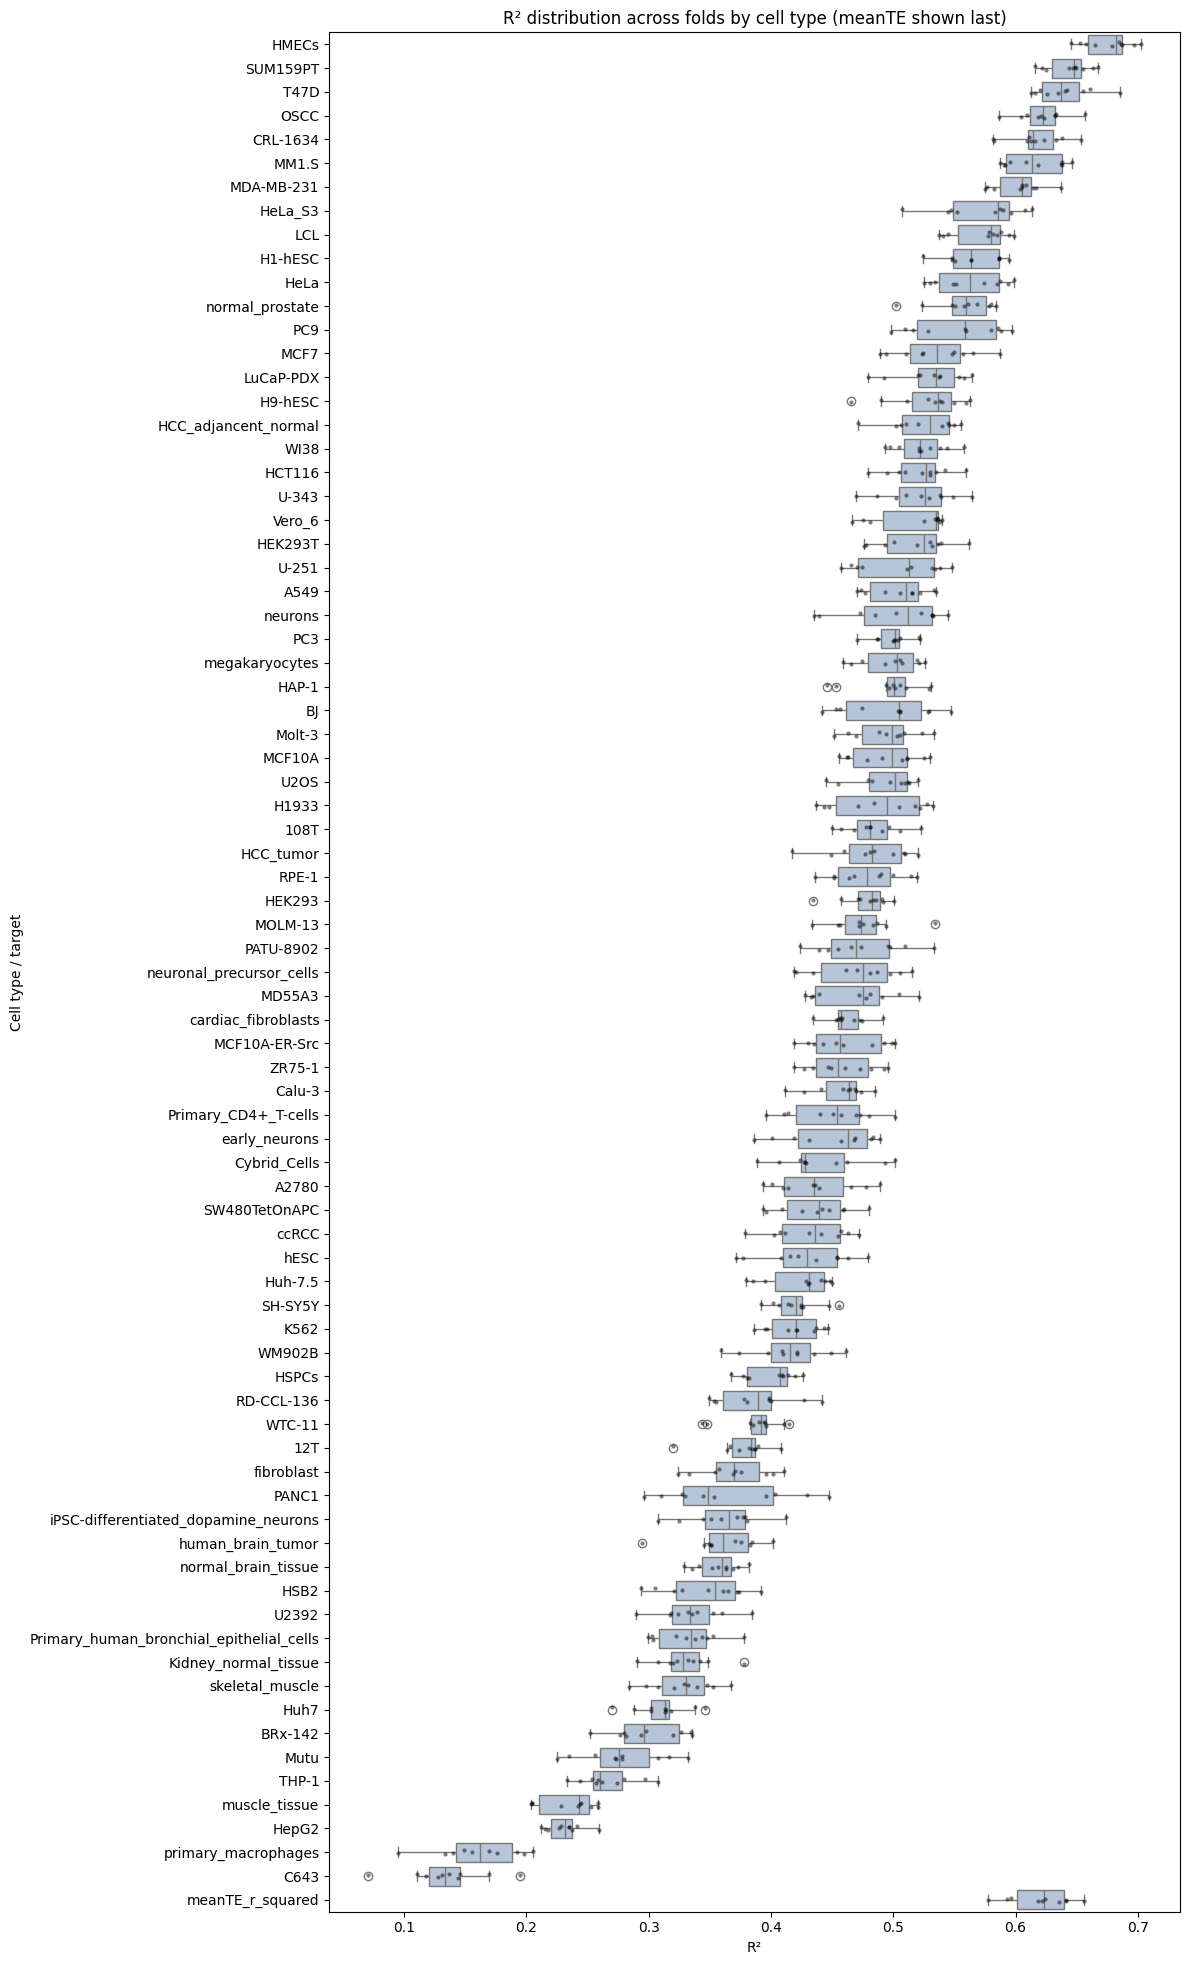

In [98]:
# Boxplot of per-fold R^2 for each cell type, with meanTE metric forced to the end
plot_cols = [c for c in results.columns if c not in ["fold", "overall_r_squared"]]
r2_long = results[plot_cols].melt(var_name="target", value_name="r_squared")

# Order all non-mean targets by mean R^2 (descending), then append mean target last
order_rest = (
    r2_long.loc[r2_long["target"] != "meanTE_r_squared"]
    .groupby("target")["r_squared"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)
order = order_rest + ["meanTE_r_squared"]

plt.figure(figsize=(12, max(8, len(order) * 0.25)))
sns.boxplot(data=r2_long, y="target", x="r_squared", order=order, color="lightsteelblue")
sns.stripplot(data=r2_long, y="target", x="r_squared", order=order, color="black", size=3, alpha=0.5)

plt.title("R² distribution across folds by cell type (meanTE shown last)")
plt.xlabel("R²")
plt.ylabel("Cell type / target")
plt.tight_layout()
plt.show()

### Trying to reproduce the results by running inference for a specific fold to be used as benchmark

In [99]:
human_runs  = pd.read_csv("/home/ghassan_unix/MA2/RiboNN/models/human/runs.csv")
human_runs

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.lr-AdamW,metrics.test_pearson,metrics.epoch,metrics.test_spearman,...,tags.Mode,tags.mlflow.note.content,tags.mlflow.parentRunId,tags.mlflow.rootRunId,tags.mlflow.source.name,tags.mlflow.source.git.commit,tags.mlflow.log-model.history,tags.mlflow.runName,tags.mlflow.user,tags.mlflow.source.type
0,057db008d02743f4b319c5961b00ed41,3783008913534056,FINISHED,dbfs:/databricks/mlflow-tracking/3783008913534...,2023-09-25 20:11:19.860000+00:00,2023-09-25 21:36:14.805000+00:00,0.000006,0.721142,200.0,0.709457,...,testing,Test fold: 9. Validation fold: 8,8c8e8a779da245d1a5dd90af1d63787b,8c8e8a779da245d1a5dd90af1d63787b,/cloud-home/I0554398/oneai-mrc-mrna_design_and...,435215584668198691c7be4caabd29c71fde43ee,"[{""artifact_path"":""model"",""flavors"":{""pytorch""...",skillful-shrike-836,Dinghai.Zheng@sanofi.com,LOCAL
1,9143579890a34b8185275db54d5232cc,3783008913534056,FINISHED,dbfs:/databricks/mlflow-tracking/3783008913534...,2023-09-25 18:45:32.665000+00:00,2023-09-25 20:11:19.700000+00:00,0.000001,0.710018,200.0,0.699032,...,testing,Test fold: 9. Validation fold: 7,8c8e8a779da245d1a5dd90af1d63787b,8c8e8a779da245d1a5dd90af1d63787b,/cloud-home/I0554398/oneai-mrc-mrna_design_and...,435215584668198691c7be4caabd29c71fde43ee,"[{""artifact_path"":""model"",""flavors"":{""pytorch""...",abrasive-dolphin-70,Dinghai.Zheng@sanofi.com,LOCAL
2,7b60785f84d84eaeb9b2a62b84a276cd,3783008913534056,FINISHED,dbfs:/databricks/mlflow-tracking/3783008913534...,2023-09-25 17:17:26.238000+00:00,2023-09-25 18:45:32.523000+00:00,0.000001,0.713604,200.0,0.703914,...,testing,Test fold: 9. Validation fold: 6,8c8e8a779da245d1a5dd90af1d63787b,8c8e8a779da245d1a5dd90af1d63787b,/cloud-home/I0554398/oneai-mrc-mrna_design_and...,435215584668198691c7be4caabd29c71fde43ee,"[{""artifact_path"":""model"",""flavors"":{""pytorch""...",serious-midge-203,Dinghai.Zheng@sanofi.com,LOCAL
3,644d797500e24d22aebfd58c7ac5a403,3783008913534056,FINISHED,dbfs:/databricks/mlflow-tracking/3783008913534...,2023-09-25 15:44:17.916000+00:00,2023-09-25 17:17:26.063000+00:00,0.000001,0.709025,200.0,0.699156,...,testing,Test fold: 9. Validation fold: 5,8c8e8a779da245d1a5dd90af1d63787b,8c8e8a779da245d1a5dd90af1d63787b,/cloud-home/I0554398/oneai-mrc-mrna_design_and...,435215584668198691c7be4caabd29c71fde43ee,"[{""artifact_path"":""model"",""flavors"":{""pytorch""...",chill-ant-929,Dinghai.Zheng@sanofi.com,LOCAL
4,f0d91ad02e584847a51cfbac39e9cb28,3783008913534056,FINISHED,dbfs:/databricks/mlflow-tracking/3783008913534...,2023-09-25 14:17:05.468000+00:00,2023-09-25 15:44:17.782000+00:00,0.000001,0.710123,200.0,0.699479,...,testing,Test fold: 9. Validation fold: 4,8c8e8a779da245d1a5dd90af1d63787b,8c8e8a779da245d1a5dd90af1d63787b,/cloud-home/I0554398/oneai-mrc-mrna_design_and...,435215584668198691c7be4caabd29c71fde43ee,"[{""artifact_path"":""model"",""flavors"":{""pytorch""...",gifted-calf-343,Dinghai.Zheng@sanofi.com,LOCAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,5aa149a922834dd89c15adb9f04255df,3783008913534056,FINISHED,dbfs:/databricks/mlflow-tracking/3783008913534...,2023-09-20 21:42:59.051000+00:00,2023-09-20 23:04:29.888000+00:00,0.000013,0.712630,200.0,0.702270,...,testing,Test fold: 0. Validation fold: 4,8c8e8a779da245d1a5dd90af1d63787b,8c8e8a779da245d1a5dd90af1d63787b,/cloud-home/I0554398/oneai-mrc-mrna_design_and...,435215584668198691c7be4caabd29c71fde43ee,"[{""artifact_path"":""model"",""flavors"":{""pytorch""...",legendary-bird-724,Dinghai.Zheng@sanofi.com,LOCAL
86,6c1a41c776fe43feb13db0b539ac7d02,3783008913534056,FINISHED,dbfs:/databricks/mlflow-tracking/3783008913534...,2023-09-20 20:20:48.679000+00:00,2023-09-20 21:42:58.928000+00:00,0.000002,0.708391,200.0,0.697180,...,testing,Test fold: 0. Validation fold: 3,8c8e8a779da245d1a5dd90af1d63787b,8c8e8a779da245d1a5dd90af1d63787b,/cloud-home/I0554398/oneai-mrc-mrna_design_and...,435215584668198691c7be4caabd29c71fde43ee,"[{""ar

In [103]:
reduced = human_runs[["params.valid_fold", "params.inner_cv_folds", "params.test_fold", "params.outer_cv_folds"]]
reduced.head()

,params.valid_fold,params.inner_cv_folds,params.test_fold,params.outer_cv_folds
0,8,9,9,10
1,7,9,9,10
2,6,9,9,10
3,5,9,9,10
4,4,9,9,10


The technique used for inference is nested cross-validation. For a given sequence, the algorithm uses 10 models trained on different folds to predict the TE for that sequence. The value `params.test_fold` in `runs.csv` indicates, for each model, which of the 10 folds it hasn't seen at all. For test_fold = 0, there are 9 such models. Each of these models was trained on 8 of the 9 remaining folds and validated on the 1 fold that was left out. 

At inference, we pick, for each of the 10 folds, 1 model out of 9 (or more if top_k > 1) that performed best on the validation fold. We then ensemble the predictions of these 10 models to get the final predicted TE for each sequence. 

In [105]:
fold_groups = df_real.groupby("fold")
for fold, group in fold_groups:
    print(f"Fold {fold} - number of sequences: {len(group)}")
    subdf = group.loc[:, ["tx_id", "tx_sequence", "utr5_size", "cds_size"]]
    output_path = f"/home/ghassan_unix/MA2/RiboNN/data/fold_{fold}_input.txt"
    subdf.to_csv(output_path, sep="\t", index=False)
    print(f"Saved: {output_path}")




Fold 0 - number of sequences: 1045
Saved: /home/ghassan_unix/MA2/RiboNN/data/fold_0_input.txt
Fold 1 - number of sequences: 1063
Saved: /home/ghassan_unix/MA2/RiboNN/data/fold_1_input.txt
Fold 2 - number of sequences: 1114
Saved: /home/ghassan_unix/MA2/RiboNN/data/fold_2_input.txt
Fold 3 - number of sequences: 954
Saved: /home/ghassan_unix/MA2/RiboNN/data/fold_3_input.txt
Fold 4 - number of sequences: 1011
Saved: /home/ghassan_unix/MA2/RiboNN/data/fold_4_input.txt
Fold 5 - number of sequences: 1028
Saved: /home/ghassan_unix/MA2/RiboNN/data/fold_5_input.txt
Fold 6 - number of sequences: 1020
Saved: /home/ghassan_unix/MA2/RiboNN/data/fold_6_input.txt
Fold 7 - number of sequences: 1031
Saved: /home/ghassan_unix/MA2/RiboNN/data/fold_7_input.txt
Fold 8 - number of sequences: 1058
Saved: /home/ghassan_unix/MA2/RiboNN/data/fold_8_input.txt
Fold 9 - number of sequences: 1024
Saved: /home/ghassan_unix/MA2/RiboNN/data/fold_9_input.txt
